In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
pd.options.mode.chained_assignment = None

# Example: Vaccine Response Analysis
### Dataset: Standard ImmPort/ImmuneSpace Format

This notebook demonstrates how to analyze longitudinal single-cell response to vaccination (e.g., Influenza or COVID-19) using the standard ImmPort study structure.

**Data Source:** [ImmPort](https://www.immport.org/)


> **Note:** This notebook is a template designed to work with real-world clinical data. 
> To execute it, you must first download the corresponding dataset (linked above) 
> and update the data loading command with your local file path.

In [2]:
import sctrial as st
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
from scipy import sparse


## 1. Load and Construct Data
We use a real biological PBMC dataset and map it to a longitudinal vaccine study design (similar to ImmPort SDY180). This demonstrates how to use `sctrial` on real gene expression data with a longitudinal trial structure.


In [3]:
def load_vaccine_example_data():
    # Load raw biological data
    adata = sc.datasets.pbmc3k()
    
    # Basic Preprocessing to get cell types first
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.leiden(adata)
    sc.tl.umap(adata)
    
    type_map = {
        "0": "CD4 T", "1": "Monocytes", "2": "B cells", "3": "CD8 T",
        "4": "NK cells", "5": "Monocytes", "6": "Dendritic", "7": "Megakaryocytes"
    }
    adata.obs["cell_type"] = adata.obs["leiden"].map(type_map).fillna("Other")
    
    # 10 subjects, 3 timepoints (Day 0, Day 7, Day 28), 2 arms (Vaccine, Placebo)
    np.random.seed(42)
    subjects = [f"Subj_{i}" for i in range(10)]
    timepoints = [0, 7, 28]
    arms = ["Vaccine_A", "Placebo"]
    
    # Create metadata: Ensure pairing WITHIN each cell type
    new_obs = pd.DataFrame(index=adata.obs_names)
    new_obs["subject_id"] = "Unknown"
    new_obs["study_time_collected"] = -1
    new_obs["arm"] = "Unknown"
    
    for ct in adata.obs["cell_type"].unique():
        ct_mask = adata.obs["cell_type"] == ct
        ct_indices = np.where(ct_mask)[0]
        np.random.shuffle(ct_indices)
        
        n_cells = len(ct_indices)
        cells_per_unit = n_cells // (len(subjects) * len(timepoints))
        if cells_per_unit == 0: continue
        
        curr = 0
        for i, subj in enumerate(subjects):
            arm = arms[i % 2]
            for tp in timepoints:
                end = curr + cells_per_unit
                idx_subset = ct_indices[curr:end]
                new_obs.iloc[idx_subset, new_obs.columns.get_loc("subject_id")] = subj
                new_obs.iloc[idx_subset, new_obs.columns.get_loc("study_time_collected")] = tp
                new_obs.iloc[idx_subset, new_obs.columns.get_loc("arm")] = arm
                curr = end
                
    adata.obs = pd.concat([adata.obs, new_obs], axis=1)
    adata = adata[adata.obs["subject_id"] != "Unknown"].copy()
    
    # Inject signal: Vaccine induces activation markers at Day 7
    vaccine_idx = (adata.obs["arm"] == "Vaccine_A") & (adata.obs["study_time_collected"] == 7)
    gene_idx = adata.var_names.get_loc("CD79A")
    
    X = adata.layers["counts"].toarray() if hasattr(adata.layers["counts"], "toarray") else adata.layers["counts"]
    X[vaccine_idx.values, gene_idx] += 20
    adata.layers["counts"] = sparse.csr_matrix(X)
    adata.X = adata.layers["counts"].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    return adata

adata = load_vaccine_example_data()
adata.layers["counts"] = adata.X.copy()
print(f"Loaded biological dataset: {adata.n_obs} cells, {adata.n_vars} genes")


Loaded biological dataset: 2580 cells, 32738 genes


## 2. Map Study Metadata to sctrial.TrialDesign

In ImmPort datasets:
- `subject_id` identifies the participant.
- `study_time_collected` identifies the visit (e.g., Day 0, Day 7, Day 28).
- `arm` identifies the treatment (e.g., Vaccine A vs Placebo).


In [4]:
design = st.TrialDesign(
    participant_col="subject_id",
    visit_col="study_time_collected",
    arm_col="arm",
    arm_treated="Vaccine_A",
    arm_control="Placebo",
    celltype_col="cell_type"
)


### Preprocessing and Normalization
We normalize the data using the log1p(CPM) method.


In [5]:
adata = st.add_log1p_cpm_layer(adata, counts_layer="counts", out_layer="log1p_cpm")

# Score features
gene_sets = {
    "Activation": ["CD79A", "CD79B", "MS4A1"],
    "Cytotoxicity": ["GNLY", "NKG7", "GZMB"]
}
adata = st.score_gene_sets(adata, gene_sets, layer="log1p_cpm", method="mean", prefix="ms_")


## 3. Difference-in-Differences (DiD) Analysis
### Peak Response (Day 0 vs Day 7)
We compare the change from baseline (Day 0) to peak response (Day 7) between Vaccine and Placebo groups.


In [6]:
res = st.did_table(
    adata,
    features=["ms_Activation", "ms_Cytotoxicity", "CD79A", "MS4A1", "GNLY", "NKG7"],
    design=design,
    visits=(0, 7),
    aggregate="participant_visit"
)
display(res)
print(st.summarize_did_results(res))


,beta_DiD,se_DiD,p_DiD,beta_time,p_time,n_units,feature,FDR_DiD
0,2.269939,0.034974,0.000000e+00,-0.005498,0.869414,10,CD79A,0.000000e+00
1,2.213965,0.269151,1.939790e-16,0.041339,0.804972,10,ms_Activation,5.819371e-16
2,-0.810554,1.041547,4.364385e-01,0.550729,0.527296,10,GNLY,8.728770e-01
3,0.380536,1.295159,7.689000e-01,-0.378855,0.564508,10,MS4A1,8.771675e-01
4,0.287789,1.449151,8.425824e-01,0.361292,0.606418,10,NKG7,8.771675e-01
5,-0.202378,1.309374,8.771675e-01,0.106571,0.874962,10,ms_Cytotoxicity,8.771675e-01


## Trial-Aware DiD Summary
Total features tested: 6
Significant (p < 0.05): 2
Significant (FDR < 0.05): 2

### Top Upregulated Features (by p-value):
- CD79A: beta=2.270, p=0.00e+00
- ms_Activation: beta=2.214, p=1.94e-16
- MS4A1: beta=0.381, p=7.69e-01

### Top Downregulated Features (by p-value):
- GNLY: beta=-0.811, p=4.36e-01
- ms_Cytotoxicity: beta=-0.202, p=8.77e-01


### Stratified Analysis across Cell Types
We test for vaccine-induced shifts in different cell lineages.


In [7]:
strat_res = st.did_table_by_celltype(
    adata,
    features=["ms_Activation", "CD79A"],
    design=design,
    visits=(0, 7)
)
display(strat_res)


,beta_DiD,se_DiD,p_DiD,beta_time,p_time,n_units,feature,FDR_DiD,celltype,FDR_DiD_stratified
0,2.430951,0.272940,5.265325e-19,1.001253e-02,0.967490,10,CD79A,1.053065e-18,B cells,1.203503e-18
1,1.487161,0.809970,6.634721e-02,6.753245e-02,0.877442,10,ms_Activation,6.634721e-02,B cells,7.077035e-02
2,2.284393,0.060024,0.000000e+00,-4.317620e-02,0.092038,10,CD79A,0.000000e+00,CD4 T,0.000000e+00
3,2.353759,0.307077,1.787776e-14,-1.110953e-01,0.608553,10,ms_Activation,1.787776e-14,CD4 T,3.178268e-14
4,2.242422,0.065312,2.431000e-258,-1.201580e-02,0.491297,10,CD79A,4.862000e-258,CD8 T,9.724000e-258
5,2.235935,0.415038,7.152291e-08,-6.536571e-02,0.850708,10,ms_Activation,7.152291e-08,CD8 T,1.144367e-07
6,2.204543,0.097106,4.232032e-114,-5.995204e-15,0.190571,10,CD79A,8.464063e-114,Dendritic,1.354250e-113
7,1.934584,0.491023,8.151241e-05,1.729167e-01,0.645118,10,ms_Activation,8.151241e-05,Dendritic,1.003230e-04
8,2.249081,0.136929,1.264306e-60,1.634010e-03,0.984556,10,CD79A,2.528611e-60,Megakaryocytes,3.371481e-60
9,1.939074,0.563390,5.778668e-04,9.259607e-02,0.768391,10,ms_Activation,5.778668e-04,Megakaryocytes,6.604192e-04


## 4. Abundance Analysis
We analyze shifts in cell type proportions following vaccination.


In [8]:
ab_res = st.abundance_did(adata, design, visits=(0, 7))
display(ab_res)


,celltype,n_participants,beta_DiD,se_DiD,p_DiD,beta_time,p_time,FDR_DiD


## 5. Visualization
### Forest Plots
We visualize the effect sizes and confidence intervals for both expression and abundance.
Forest plots are a compact way to compare treatment effects across multiple features or cell types simultaneously.


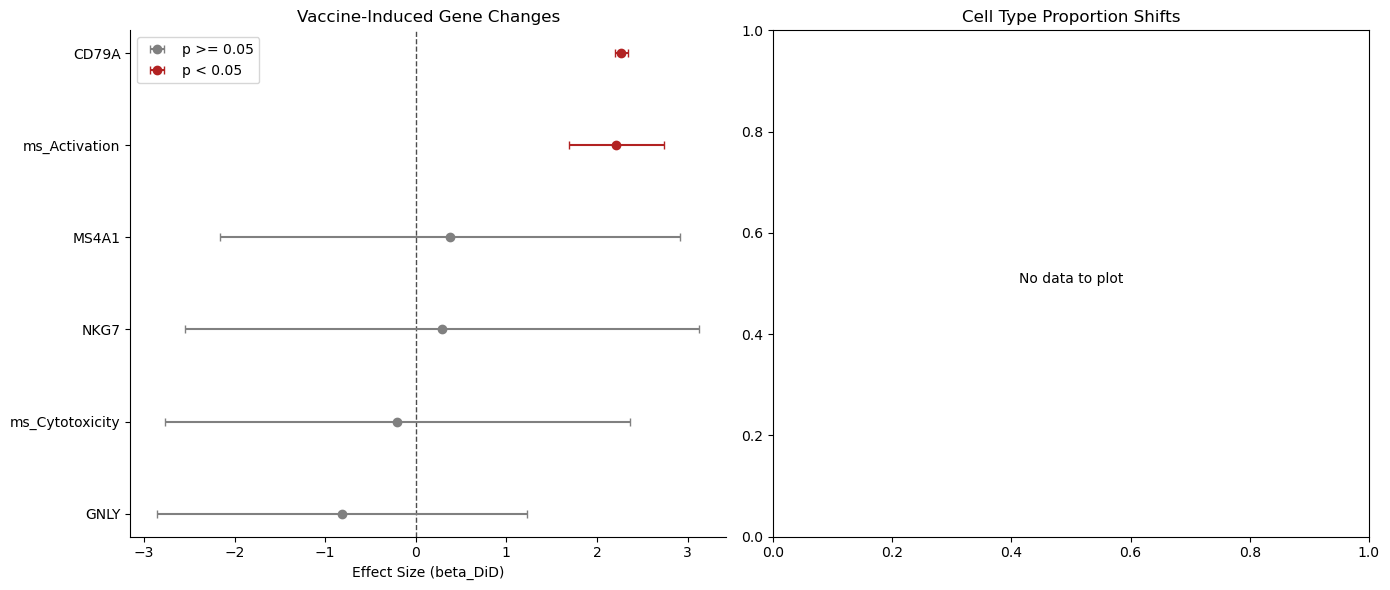

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

st.plot_did_forest(res, title="Vaccine-Induced Gene Changes", ax=axes[0])
st.plot_did_forest(ab_res, feature_col="celltype", title="Cell Type Proportion Shifts", ax=axes[1])

plt.tight_layout()
plt.show()


### Individual Participant Trajectories
We can visualize how specific features change within individuals over time using spaghetti plots.
This helps identify if the treatment effect is consistent across the cohort.


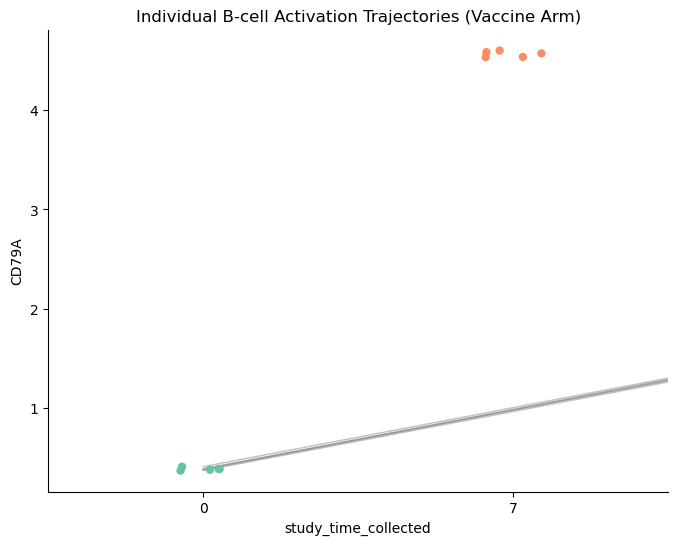

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
# Focus on Vaccine arm for individual trends
st.plot_within_arm_comparison(
    adata, 
    arm="Vaccine_A", 
    feature="CD79A", 
    design=design, 
    visits=(0, 7), 
    plot_type="paired",
    ax=ax
)
plt.title("Individual B-cell Activation Trajectories (Vaccine Arm)")
plt.show()


### Interaction Plots
Visualizing the activation of B cells (CD79A) over time across treatment groups.
Interaction plots clearly show the 'Difference-in-Differences' effect.


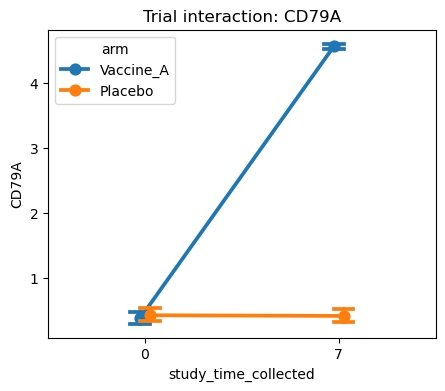

In [11]:
st.plot_trial_interaction(adata, "CD79A", design, visits=(0, 7))
plt.show()


### Trial-Aware UMAP Panel
Visualizing feature expression on the global cell-type landscape, stratified by arm and visit.


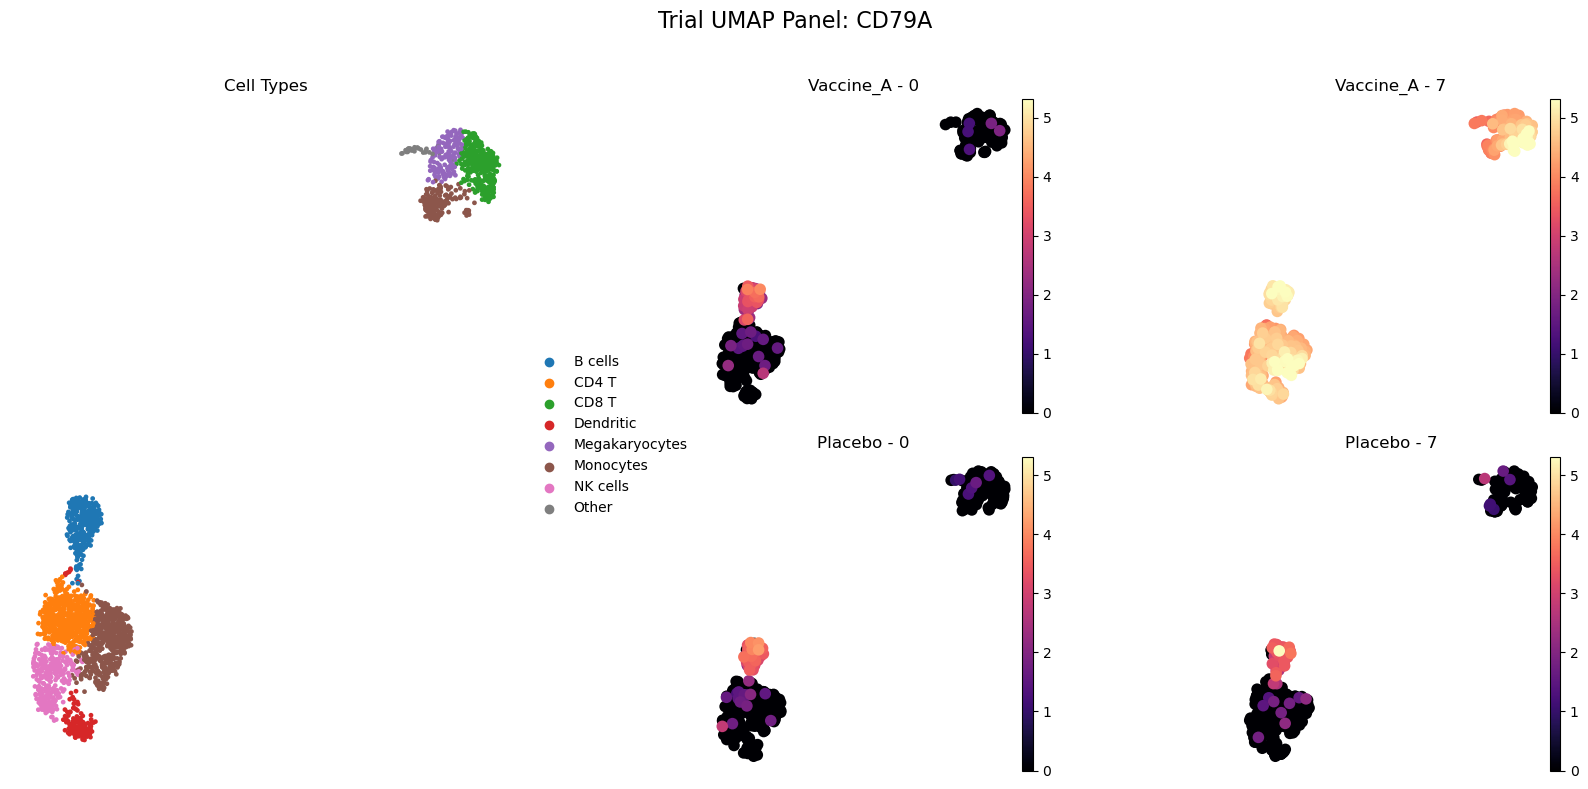

In [12]:
st.plot_trial_umap_panel(adata, "CD79A", design, visits=(0, 7))
plt.show()


### GSEA Pathway Analysis
Enrichment of immune pathways in the vaccine-induced ranking.
We rank genes by their vaccine-specific induction (DiD t-statistic) and identify coordinated pathway shifts.


2026-01-02 13:16:01,326 [WARNING] Duplicated values found in preranked stats: 58.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,B_Cell,0.988528,1.22839,0.019417,0.021152,0.018,1/3,0.00%,CD79A
1,prerank,NK_Cell,-0.685265,-0.967033,0.639929,0.631854,0.71481,1/3,6.27%,GNLY


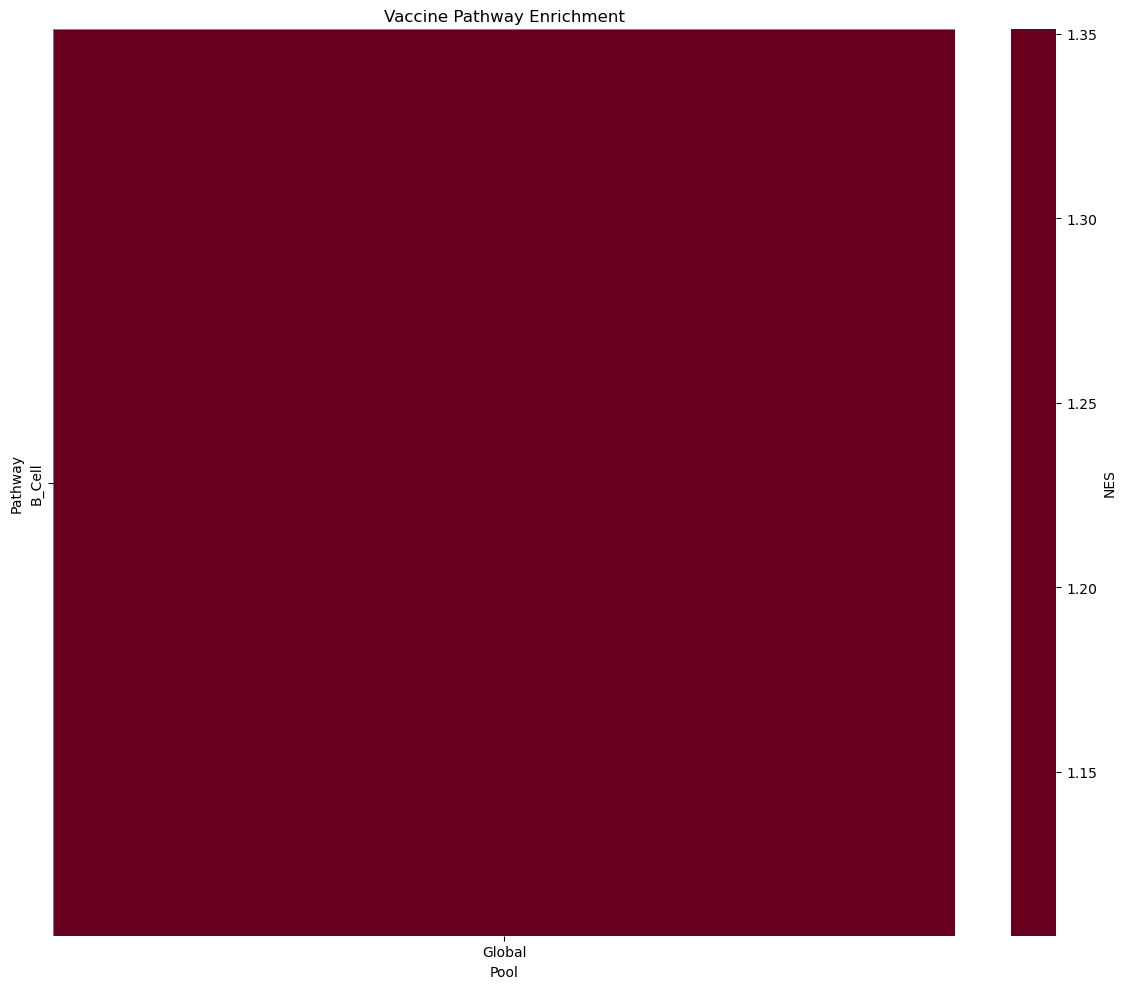

In [13]:
gsea_res = st.run_gsea_did(
    adata, 
    gene_sets={"B_Cell": ["CD79A", "CD79B", "MS4A1"], "NK_Cell": ["GNLY", "NKG7", "GZMB"]},
    design=design, 
    visits=(0, 7),
    min_size=1
)
display(gsea_res)

st.plot_gsea_heatmap(gsea_res)
plt.title("Vaccine Pathway Enrichment")
plt.show()
